In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import torch.nn.functional as F
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

import pkbar

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('data/cmod_clean_200ms.csv', sep=',', index_col=None)

shot_filter = df.isna() | df.isin([np.inf, -np.inf])
columns_w_nans = df.columns[shot_filter.any()].tolist()

df = df.drop(columns=['Unnamed: 0'], axis=1)
df = df.drop(columns_w_nans, axis=1)

WINDOW = 25
STRIDE = 2  # new window every 10 timesteps

def build_sequences_sliding(df, window, stride):
    sequences, labels = [], []
    for shot_id, group in df.groupby('shot'):
        label = group['disruptive'].iloc[-1]  # one label per shot
        vals = group.drop(
            columns=['shot', 'time_until_disrupt', 'disruptive'], errors='ignore'
        ).to_numpy(dtype='float32')
        if len(vals) < window:
            continue  # skip shots shorter than window
        for start in range(0, len(vals) - window + 1, stride):
            sequences.append(vals[start:start + window])
            labels.append(label)
    return np.array(sequences, dtype='float32'), np.array(labels, dtype='float32')

sequences, labels = build_sequences_sliding(df, WINDOW, STRIDE)
print("Number of sequences:", len(sequences))
print("Sequences shape:", sequences.shape)  # (num_sequences, 50, num_features)
print("Disruptive:", labels.sum(), "/ Non-disruptive:", (1-labels).sum())

Number of sequences: 149423
Sequences shape: (149423, 25, 43)
Disruptive: 30380.0 / Non-disruptive: 119043.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_classification = pd.read_csv(
    'data/cmod_clean_200ms.csv',
    sep=',',
    index_col=None
)

shot_filter = df_classification.isna() | df_classification.isin([np.inf, -np.inf])

columns_w_nans = df_classification.columns[shot_filter.any()].tolist()

df_classification = df_classification.drop(
    columns=['shot', 'Unnamed: 0'],
    axis=1
)

df_classification = df_classification.drop(
    columns_w_nans,
    axis=1
)

df_classification = df_classification.sample(frac=1.0)

df_classification

,time,a_minor,beta_n,beta_p,chisq,dbetap_dt,dip_dt,dip_smoothed,dipprog_dt,dli_dt,...,v_loop,v_loop_efit,v_surf,v_z,wmhd,z_error,z_prog,z_times_v_z,zcur,disruptive
277191,0.24,0.233301,-0.057762,-0.054678,11.670278,-0.030329,-7.779584e+05,7.197339e+05,-1.598582e-13,2.472246,...,1.211163,1.751425,1.358817,0.541227,-4206.817383,-0.000160,0.000000,-0.000087,-0.000160,0
337164,0.86,0.222491,0.456510,0.184885,12.140684,0.108176,-1.962219e+06,-7.196258e+05,-8.526832e-13,0.062437,...,-1.322968,-1.545993,-1.557778,-1.386306,50670.652344,0.000065,-0.009000,0.012389,-0.008935,0
92065,1.28,0.219653,0.376552,0.172109,14.714594,-0.329429,7.470427e+03,3.955047e+03,1.705268e-12,0.160633,...,-1.411397,-1.254436,-1.405151,0.030806,46095.054688,0.000351,-0.009000,-0.000265,-0.008649,0
361464,0.82,0.213977,0.864098,0.341707,16.880276,-7.105623,2.015951e+06,-2.158077e+05,-8.525880e-13,1.410372,...,1.100138,0.955837,1.043589,2.777739,153746.828125,0.003967,-0.005000,-0.002867,-0.001033,0
52566,0.44,0.222461,0.233918,0.130133,12.497617,0.103455,-2.329500e+06,2.607060e+05,1.420794e-13,0.232030,...,-0.529649,-0.834750,-1.258235,5.405740,24137.482422,0.000877,-0.010000,-0.049344,-0.009123,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27530,1.06,0.225926,0.529911,0.188358,6.853955,0.058388,-3.070261e+05,2.312693e+05,3.410572e-12,0.212863,...,-1.371548,-1.497219,-1.547065,0.108908,25664.535156,-0.000383,-0.003371,-0.000409,-0.003754,0
329857,0.92,0.223664,0.363365,0.152071,17.056271,-0.012154,2.739148e+06,-5.854885e+05,-2.557922e-12,0.104603,...,1.678202,1.849442,1.781240,-2.935243,47462.906250,-0.000560,-0.027359,0.081942,-0.027919,0
77992,0.90,0.225169,0.565365,0.367402,7.336856,3.167594,-2.378900e+05,-1.560116e+06,1.421053e-12,-1.967924,...,-1.431157,-1.163108,-0.763995,7.031423,59473.437500,-0.000204,-0.003000,-0.022524,-0.003204,0
163073,1.28,0.223733,0.407565,0.218783,14.178304,0.145970,3.909043e+05,7.168927e+05,1.705268e-12,0.495184,...,-1.645894,-1.732417,-1.683532,2.281890,40330.667969,0.000906,-0.005000,-0.009349,-0.004094,0


array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'a_minor'}>,
        <Axes: title={'center': 'beta_n'}>,
        <Axes: title={'center': 'beta_p'}>,
        <Axes: title={'center': 'chisq'}>,
        <Axes: title={'center': 'dbetap_dt'}>,
        <Axes: title={'center': 'dip_dt'}>],
       [<Axes: title={'center': 'dip_smoothed'}>,
        <Axes: title={'center': 'dipprog_dt'}>,
        <Axes: title={'center': 'dli_dt'}>,
        <Axes: title={'center': 'dn_dt'}>,
        <Axes: title={'center': 'dwmhd_dt'}>,
        <Axes: title={'center': 'greenwald_fraction'}>,
        <Axes: title={'center': 'ip'}>],
       [<Axes: title={'center': 'ip_error'}>,
        <Axes: title={'center': 'ip_prog'}>,
        <Axes: title={'center': 'kappa'}>,
        <Axes: title={'center': 'kappa_area'}>,
        <Axes: title={'center': 'li'}>,
        <Axes: title={'center': 'lower_gap'}>,
        <Axes: title={'center': 'n_e'}>],
       [<Axes: title={'center': 'p_icrf'}>,
       

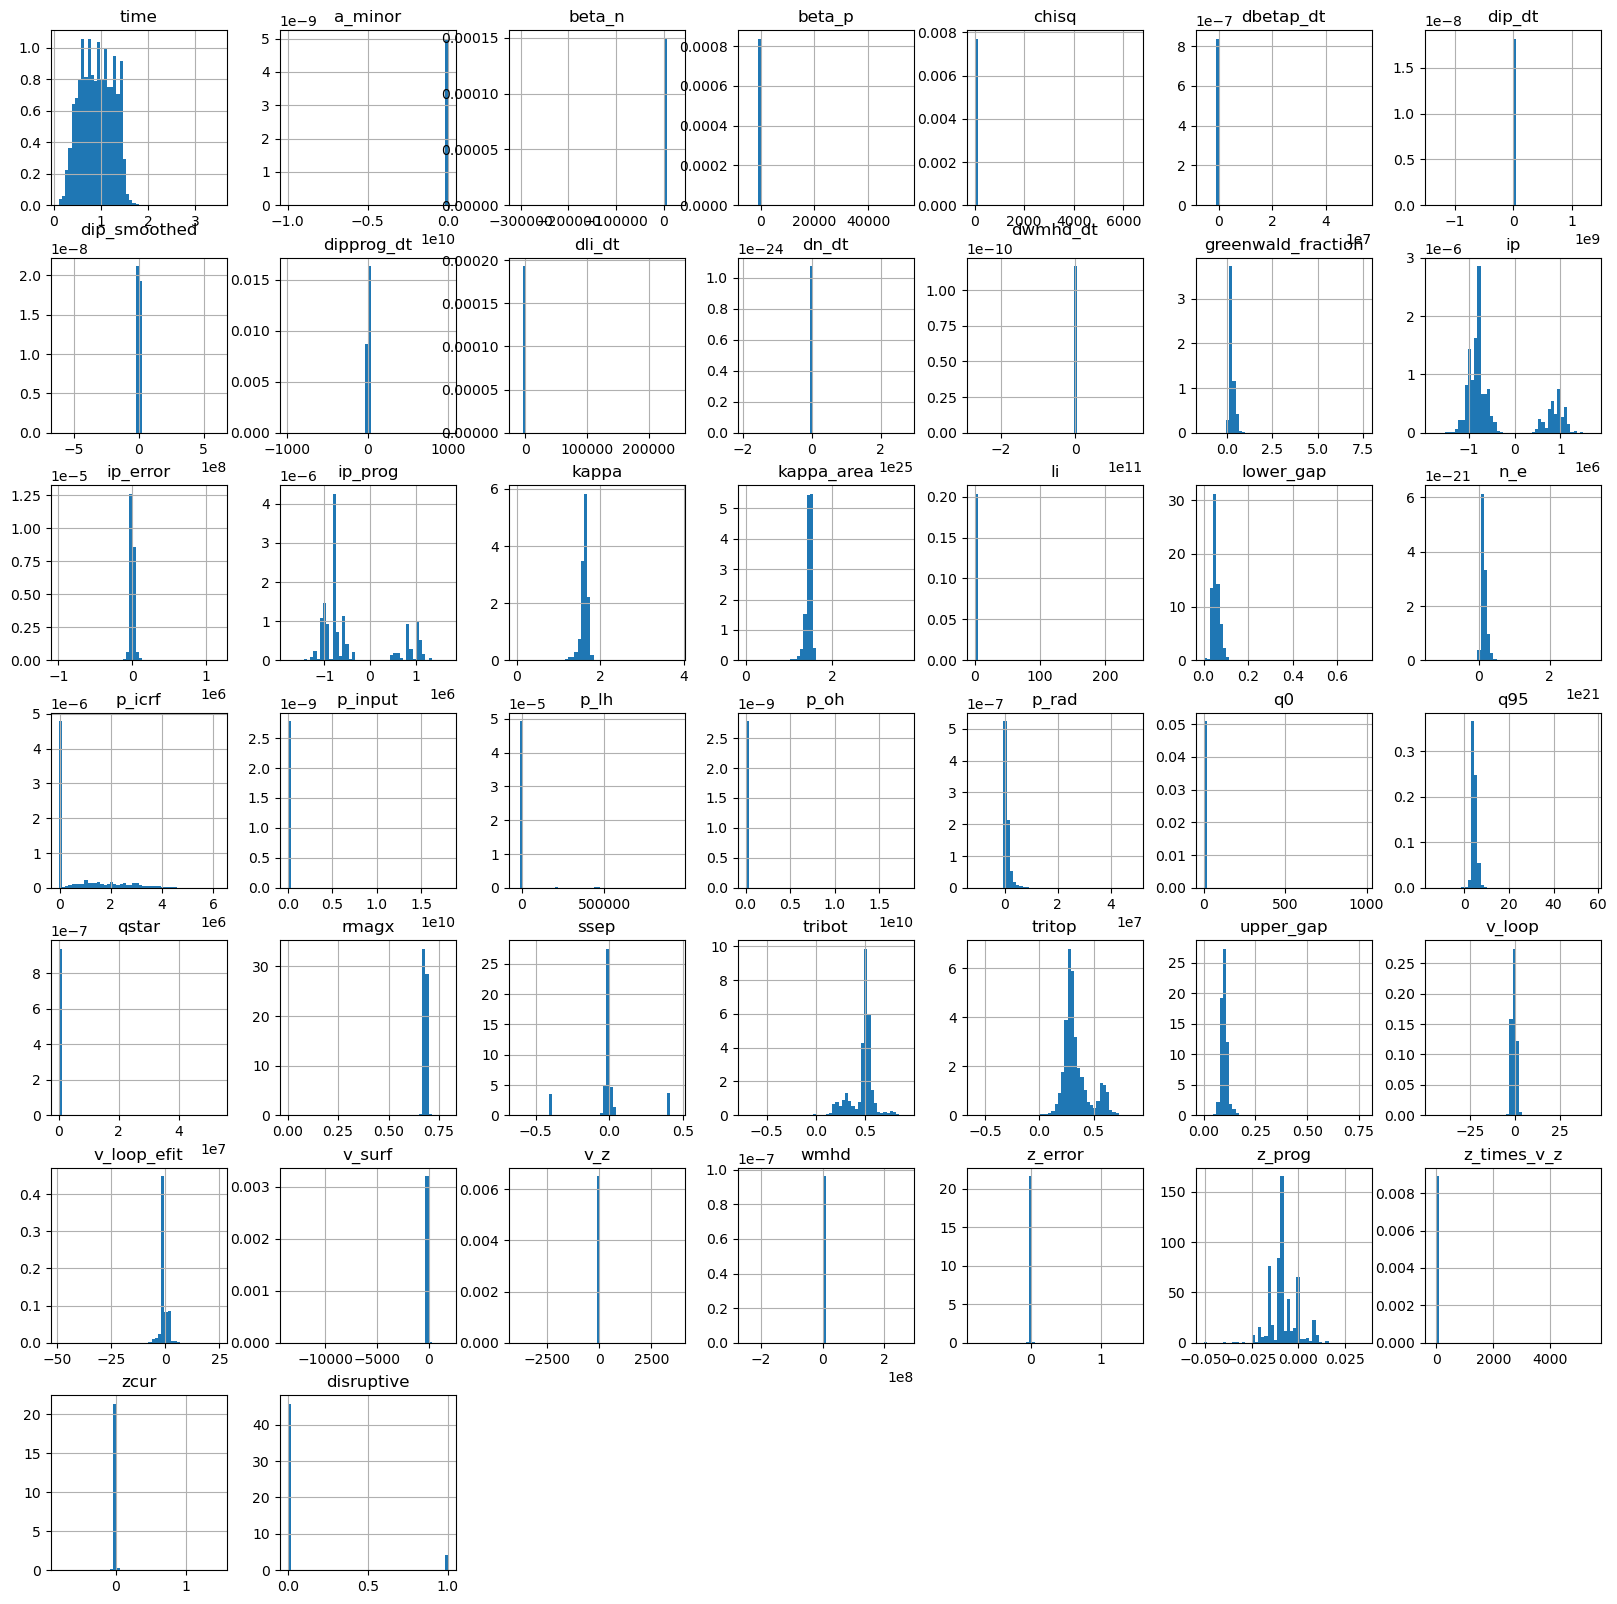

In [4]:
df_classification.hist(figsize=(20,20),bins=WINDOW,density=True)

In [5]:
n = len(sequences)
idx = np.random.permutation(n)
sequences, labels = sequences[idx], labels[idx]

n_train = int(0.7 * n)
n_val   = int(0.15 * n)

x_train, y_train = sequences[:n_train], labels[:n_train]
x_val,   y_val   = sequences[n_train:n_train+n_val], labels[n_train:n_train+n_val]
x_test,  y_test  = sequences[n_train+n_val:], labels[n_train+n_val:]

# Scale per-feature across all timesteps
# Fit on (num_train_shots * 50, num_features)
scaler = MinMaxScaler(feature_range=(-1, 1))
x_train_2d = x_train.reshape(-1, x_train.shape[-1])
scaler.fit(x_train_2d)

def scale_seqs(x):
    shape = x.shape
    return scaler.transform(x.reshape(-1, shape[-1])).reshape(shape)

x_train = scale_seqs(x_train)
x_val   = scale_seqs(x_val)
x_test  = scale_seqs(x_test)

print("Train:", x_train.shape, y_train.shape)

Train: (104596, 25, 43) (104596,)


In [9]:
import torch
import torch.nn as nn

class ShotTransformer(nn.Module):
    def predict(self,x):
        return self(x).sigmoid()
    def __init__(self, num_features, output_shape=1,
                 d_model=64, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, WINDOW, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.SELU(),
            nn.Linear(128, output_shape)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = x[:, -1, :]
        return self.classifier(x)

# Now instantiate it
classifier = ShotTransformer(
    num_features=x_train.shape[2],
    output_shape=1
)

In [10]:
classifier = ShotTransformer(
    num_features=x_train.shape[2],  # x_train is now [num_shots, 50, num_features]
    output_shape=1
)

In [11]:
classifier(torch.tensor(x_train[:3]).float())

tensor([[0.1474],
        [0.2157],
        [0.1233]], grad_fn=<AddmmBackward0>)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train.reshape(-1, 1)))
val_dataset   = TensorDataset(torch.tensor(x_val),   torch.tensor(y_val.reshape(-1, 1)))
test_dataset  = TensorDataset(torch.tensor(x_test),  torch.tensor(y_test.reshape(-1, 1)))

print(train_dataset.tensors[0].shape)  # should be (num_shots, 50, num_features)

torch.Size([104596, 25, 43])


In [13]:
train_dataset.__getitem__(0)

(tensor([[-0.5625,  1.0000,  0.9523,  ..., -0.1667,  0.1525, -0.0392],
         [-0.5507,  1.0000,  0.9523,  ..., -0.1667,  0.1519, -0.0422],
         [-0.5389,  1.0000,  0.9523,  ..., -0.1667,  0.1519, -0.0414],
         ...,
         [-0.3024,  1.0000,  0.9523,  ..., -0.1667,  0.1523, -0.0399],
         [-0.2905,  1.0000,  0.9523,  ..., -0.1667,  0.1522, -0.0452],
         [-0.2787,  1.0000,  0.9523,  ..., -0.1667,  0.1528, -0.0460]]),
 tensor([0.]))

In [14]:
!nvidia-smi

Thu Jun 11 20:27:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:81:00.0 Off |                    0 |
|  0%   26C    P8             32W /  300W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [30]:
config = {
    "seed": 8,
    "name": "ShotTransformer",
    "run_val": 1,
    "model": {
        "input_shape": x_train.shape[-1],  # num_features
        "output_shape": 1,
    },
    "optimizer": {"lr": 7e-4},
    "num_epochs": 100,
    "dataloader": {
        "train": {"batch_size": 64},
        "val":   {"batch_size": 64},
        "test":  {"batch_size": 64},
    },
    "output": {"dir": "./"}
}

In [31]:
import os
import json
import random
import pkbar
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader

def trainer(config, train_dataset, val_dataset, test_dataset):
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    random.seed(config['seed'])

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.cuda.manual_seed(config['seed'])

    exp_name = config['name']
    print(exp_name)

    output_folder = config['output']['dir']
    output_path = os.path.join(output_folder, exp_name)
    os.makedirs(output_path, exist_ok=True)

    with open(os.path.join(output_path, 'config.json'), 'w') as outfile:
        json.dump(config, outfile)

    print('Creating Loaders.')

    train_batch_size = config['dataloader']['train']['batch_size']
    val_batch_size   = config['dataloader']['val']['batch_size']
    test_batch_size  = config['dataloader']['test']['batch_size']

    # Fix 1: replace CreateLoaders with DataLoader directly
    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=val_batch_size,   shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=test_batch_size,  shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    print("Training Size:",   len(train_loader.dataset))
    print("Validation Size:", len(val_loader.dataset))

    # Fix 2: get output_shape from config, not undefined variable
    num_features = train_dataset.tensors[0].shape[2]
    output_shape = config['model']['output_shape']

    net = ShotTransformer(num_features=num_features, output_shape=output_shape)

    t_params = sum(p.numel() for p in net.parameters())
    print("Network Parameters:", t_params)

    net.to(device)

    num_epochs = int(config['num_epochs'])
    lr = float(config['optimizer']['lr'])

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, net.parameters()), lr=lr
    )

    num_steps = len(train_loader) * num_epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer=optimizer, T_max=num_steps, last_epoch=-1, eta_min=0
    )

    startEpoch  = 0
    global_step = 0

    print('===========  Optimizer  ==================:')
    print('      LR:', lr)
    print('      num_epochs:', num_epochs)
    print('')

    all_train_y = train_dataset.tensors[1].cpu().numpy().astype(int).ravel()
    class_counts  = np.bincount(all_train_y)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * len(class_weights)
    pos_weight    = torch.tensor(class_weights[1] / class_weights[0], dtype=torch.float32).to(device)

    loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for epoch in range(startEpoch, num_epochs):

        kbar = pkbar.Kbar(
            target=len(train_loader), epoch=epoch,
            num_epochs=num_epochs, width=20, always_stateful=False
        )

        net.train()
        running_loss = 0.0

        for i, data in enumerate(train_loader):
            inputs = data[0].to(device).float()
            y      = data[1].to(device).float().view(-1, 1)

            optimizer.zero_grad()
            y_hat = net(inputs)

            #weights = torch.ones_like(y)
            #weights[y == 1] = pos_weight

            loss = loss_function(y_hat, y).mean()
            train_acc = (torch.round(y_hat.sigmoid()) == y).float().mean().item()

            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * inputs.shape[0]
            kbar.update(i, values=[("loss", loss.item()), ("train_acc", train_acc)])
            global_step += 1

        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['lr'].append(scheduler.get_last_lr()[0])

        if bool(config['run_val']):
            net.eval()
            val_loss = 0.0
            val_acc  = 0.0

            with torch.no_grad():
                for i, data in enumerate(val_loader):
                    inputs = data[0].to(device).float()
                    y      = data[1].to(device).float().view(-1, 1)
                    y_hat  = net(inputs)

                    #weights = torch.ones_like(y)
                    #weights[y == 1] = pos_weight

                    loss = loss_function(y_hat, y).mean()
                    val_acc  += (torch.round(y_hat.sigmoid()) == y).float().mean().item()
                    val_loss += loss.item()

            val_loss = val_loss / len(val_loader)
            val_acc  = val_acc  / len(val_loader)
            history['val_loss'].append(val_loss)

            kbar.add(1, values=[("val_loss", val_loss), ("val_acc", val_acc)])
            name_output_file = config['name'] + '_epoch{:02d}_val_loss_{:.6f}.pth'.format(epoch, val_loss)
        else:
            kbar.add(1, values=[('val_loss', 0.)])
            name_output_file = config['name'] + '_epoch{:02d}_train_loss_{:.6f}.pth'.format(epoch, history['train_loss'][-1])

        checkpoint = {
            'net_state_dict': net.state_dict(),
            'optimizer':      optimizer.state_dict(),
            'scheduler':      scheduler.state_dict(),
            'epoch':          epoch,
            'history':        history,
            'global_step':    global_step,
        }
        torch.save(checkpoint, os.path.join(output_path, name_output_file))
        print('')

    return net, history

In [32]:
trainer(config,train_dataset,val_dataset,test_dataset)

ShotTransformer
Creating Loaders.
Training Size: 104596
Validation Size: 22413
Network Parameters: 112833
===========  Optimizer  ==================:
      LR: 0.0007
      num_epochs: 100

Epoch: 1/100
1635/1635 [====================] - 9s 5ms/step - loss: 0.8647 - train_acc: 0.7885 - val_loss: 0.7788 - val_acc: 0.8689

Epoch: 2/100
1635/1635 [====================] - 9s 5ms/step - loss: 0.7913 - train_acc: 0.8415 - val_loss: 0.7675 - val_acc: 0.8321

Epoch: 3/100
1635/1635 [====================] - 9s 5ms/step - loss: 0.7753 - train_acc: 0.8385 - val_loss: 0.7826 - val_acc: 0.7732

Epoch: 4/100
1635/1635 [====================] - 9s 5ms/step - loss: 0.7671 - train_acc: 0.8346 - val_loss: 0.7711 - val_acc: 0.8009

Epoch: 5/100
1635/1635 [====================] - 8s 5ms/step - loss: 0.7572 - train_acc: 0.8353 - val_loss: 0.7429 - val_acc: 0.8211

Epoch: 6/100
1635/1635 [====================] - 8s 5ms/step - loss: 0.7478 - train_acc: 0.8324 - val_loss: 0.7334 - val_acc: 0.8219

Epoch: 7/100

(ShotTransformer(
   (input_proj): Linear(in_features=43, out_features=64, bias=True)
   (transformer): TransformerEncoder(
     (layers): ModuleList(
       (0-1): 2 x TransformerEncoderLayer(
         (self_attn): MultiheadAttention(
           (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
         )
         (linear1): Linear(in_features=64, out_features=256, bias=True)
         (dropout): Dropout(p=0.1, inplace=False)
         (linear2): Linear(in_features=256, out_features=64, bias=True)
         (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
         (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
         (dropout1): Dropout(p=0.1, inplace=False)
         (dropout2): Dropout(p=0.1, inplace=False)
       )
     )
   )
   (classifier): Sequential(
     (0): Linear(in_features=64, out_features=128, bias=True)
     (1): SELU()
     (2): Linear(in_features=128, out_features=1, bias=True)
   )
 ),
 {'train_loss': [

In [33]:
checkpoint_dir = os.path.join(config['output']['dir'], config['name'])

pth_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")]
latest_file = sorted(pth_files)[-1]

dicte = torch.load(
    os.path.join(checkpoint_dir, latest_file),
    map_location="cpu"
)

print(dicte.keys())

dict_keys(['net_state_dict', 'optimizer', 'scheduler', 'epoch', 'history', 'global_step'])


/tmp/ipykernel_1654/4230760654.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dicte = torch.load(


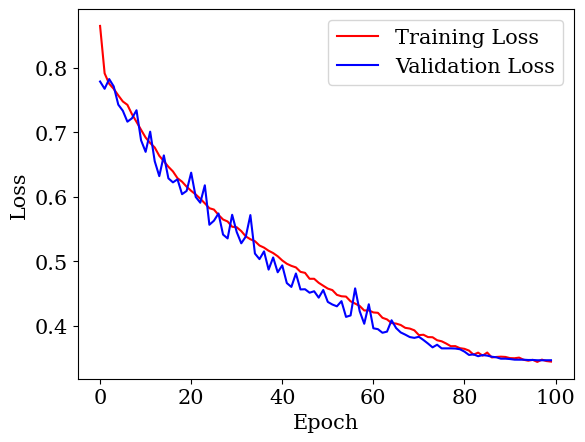

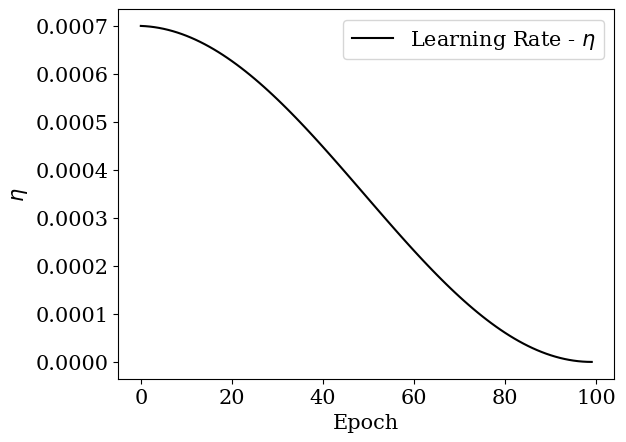

In [36]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

train_loss = dicte['history']['train_loss']
val_loss = dicte['history']['val_loss']
learning_rate = dicte['history']['lr']


plt.plot(train_loss,'r-',label="Training Loss")
plt.plot(val_loss,'b-',label='Validation Loss')
plt.legend(fontsize=15)
plt.xlabel('Epoch',fontsize=15)
plt.ylabel('Loss',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.savefig("100_Epoch_Transformer_Loss.pdf", format='pdf')
plt.show()

plt.plot(learning_rate,'k-',label=r"Learning Rate - $\eta$")
plt.legend(fontsize=15)
plt.xlabel('Epoch',fontsize=15)
plt.ylabel(r'$\eta$',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.show()


In [37]:
config['model']['input_shape'] = x_train.shape[2]  # shape[2] = 43 (features), correct
input_shape = config['model']['input_shape']
output_shape = config['model']['output_shape']

net = ShotTransformer(num_features=input_shape, output_shape=output_shape)

t_params = sum(p.numel() for p in net.parameters())
print("Network Parameters:", t_params)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)

checkpoint_dir = os.path.join(config['output']['dir'], config['name'])
pth_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")]
latest_file = sorted(pth_files)[-1]

dicte = torch.load(
    os.path.join(checkpoint_dir, latest_file),
    map_location=device,
    weights_only=False
)

net.load_state_dict(dicte["net_state_dict"])
net.eval()

Network Parameters: 112833


ShotTransformer(
  (input_proj): Linear(in_features=43, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): SELU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [38]:
test_loader = DataLoader(test_dataset,batch_size=config['dataloader']['test']['batch_size'])
net.eval() # Eval mode

predictions = []
y_true = []
kbar = pkbar.Kbar(target=len(test_loader), width=20, always_stateful=False)
for i,data in enumerate(test_loader):
    x = data[0].to('cuda').float()
    y_true.append(data[1].numpy())

    with torch.set_grad_enabled(False): # Same as with torch.no_grad():
        y_hat = net(x).sigmoid().detach().cpu().numpy()

    predictions.append(y_hat)

    kbar.update(i)

predictions = np.concatenate(predictions)
y_true = np.concatenate(y_true)

315/351 [================>...] - ETA: 0s

AUC: 0.97


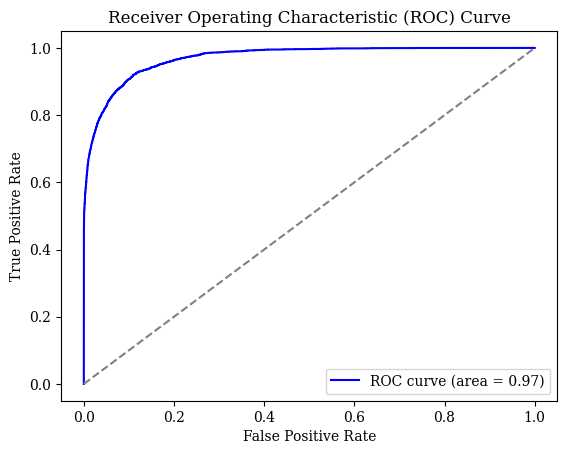

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, predictions)

# Calculate the AUC (Area Under the Curve)
auc = roc_auc_score(y_true, predictions)
print(f"AUC: {auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig("100_Epoch_Transformer_ROC.pdf", format='pdf')
plt.show()

Confusion Matrix:
 [[15957  1791]
 [  430  4236]]


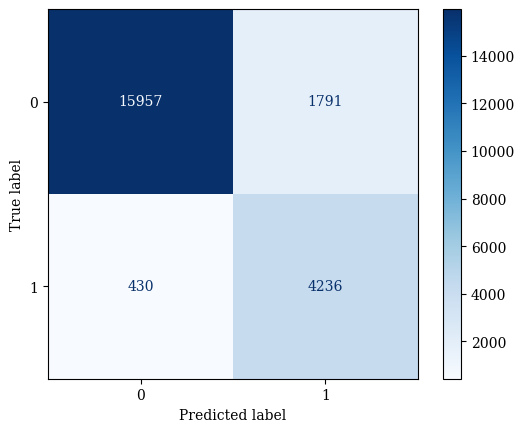

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

cm = confusion_matrix(y_true, predictions.round())
print("Confusion Matrix:\n", cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.savefig("100_Epoch_Transformer_Conf_Matrix.pdf", format='pdf')
plt.show()

In [ ]:
print(classification_report(y_true,predictions.round()))

# Compute metrics
precision = precision_score(y_true, predictions.round())
recall = recall_score(y_true, predictions.round())
f1 = f1_score(y_true, predictions.round())

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")